# Forward Repetition Access Lag-CRP

> Measure how strongly temporal neighbors cue access to repeated items.

The forward repetition access CRP measures the conditional probability of transitioning *to* an available repeated item as a function of the previous recall's lag from each repeated-item presentation. This is the forward-conditioned counterpart to the clean backward repetition CRP. The focal lags are `+1` and `+2`: transitions from the forward neighbors of the first or second presentation into the repeated item.

## Workflow

In [1]:
import matplotlib.pyplot as plt
import os
from jaxcmr.analyses.repaccesscrp import (
    plot_rep_access_crp,
    subject_rep_access_crp,
)
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

In [2]:
data_path = "../datasets/prepared/BroitmanKahana2024.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = [0, .45]
trial_query = "data['listLength'] > 0"
min_lag = 4
max_lag = 5
size = 2
confidence_level = 0.95

In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
trial_mask = generate_trial_mask(data, trial_query)

/Users/jordangunn/miniconda3/lib/python3.12/site-packages/scipy/_lib/_util.py:440: DegenerateDataWarning: The BCa confidence interval cannot be calculated. This problem is known to occur when the distribution is degenerate or the statistic is np.min.
  return fun(*args, **kwargs)


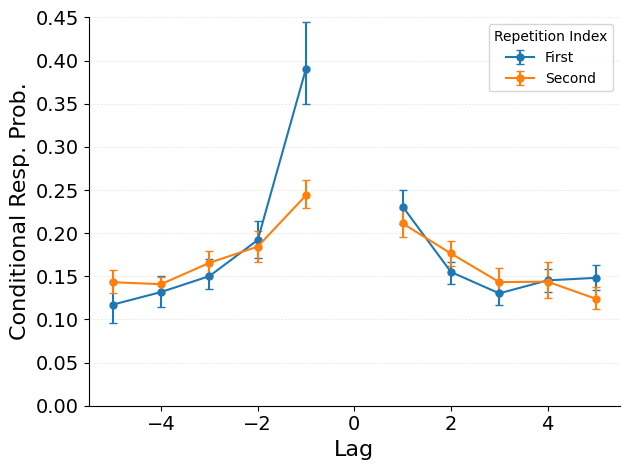

In [4]:
plot_rep_access_crp(
    datasets=data,
    trial_masks=trial_mask,
    max_lag=max_lag,
    min_lag=min_lag,
    size=size,
    confidence_level=confidence_level,
    labels=("First", "Second"),
    contrast_name="Repetition Index",
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)

## Interpretation

The plot shows forward access curves by presentation index. Key patterns:

- **Neighbor access**: lags `+1` and `+2` ask whether forward neighbors of a repeated-item presentation cue recall of the repeated item.
- **First vs. second presentation**: differences between curves reveal whether neighbors of one occurrence provide stronger access to the repeated item.

## API Details

### Notebook parameters

- `data_path` - path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` - directory for saving figures.
- `figure_str` - base filename for the saved figure. Leave empty to display without saving.
- `ylim` - y-axis limits, or `None` for automatic scaling.
- `trial_query` - query selecting trials.
- `min_lag` - minimum spacing between repeated presentations.
- `max_lag` - maximum absolute lag displayed.
- `size` - maximum number of study positions a single item can occupy.
- `confidence_level` - confidence level for subject-wise error bars.